<a href="https://colab.research.google.com/github/trungnam844-droid/Olist-E-commerce-Analytics-Customer-Segmentation-Sales-Insights-Delivery-Performance/blob/main/Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def eda_overview(df):
    print(f"1.Shape: \n{df.shape}")

    print(f"\n2.Info:")
    df.info()

    print(f"\n3.Missing values: \n{df.isnull().sum()}")

    print(f"\n4.Duplicate values: \n{df.duplicated().sum()}")

# **1. olist_customers_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1GTNW7v4ZjdVOe51V6JwqsEqRT76T9Hf_/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
customers = pd.read_csv(download_url)
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
#Overview
eda_overview(customers)

1.Shape: 
(99441, 5)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

3.Missing values: 
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

4.Duplicate values: 
0


In [ ]:
#Unique customers
print(f"Số lượng ID đơn hàng: {customers['customer_id'].nunique()}")

print(f"\nSố lượng khách hàng thực (customer_unique_id): {customers['customer_unique_id'].nunique()}")

# Xem top khách hàng mua nhiều nhất (về mặt số lượng mã customer_id được gán)
print(f"\nTop khách hàng mua nhiều nhất (về mặt số lượng mã customer_id được gán): \n{customers['customer_unique_id'].value_counts().head(5)}")

Số lượng ID đơn hàng: 99441

Số lượng khách hàng thực (customer_unique_id): 96096

Top khách hàng mua nhiều nhất (về mặt số lượng mã customer_id được gán): 
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
Name: count, dtype: int64


In [ ]:
customers[['customer_id','customer_unique_id']].isna().sum()

,0
customer_id,0
customer_unique_id,0


In [ ]:
#Top states
customers['customer_state'].value_counts().head(10)

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


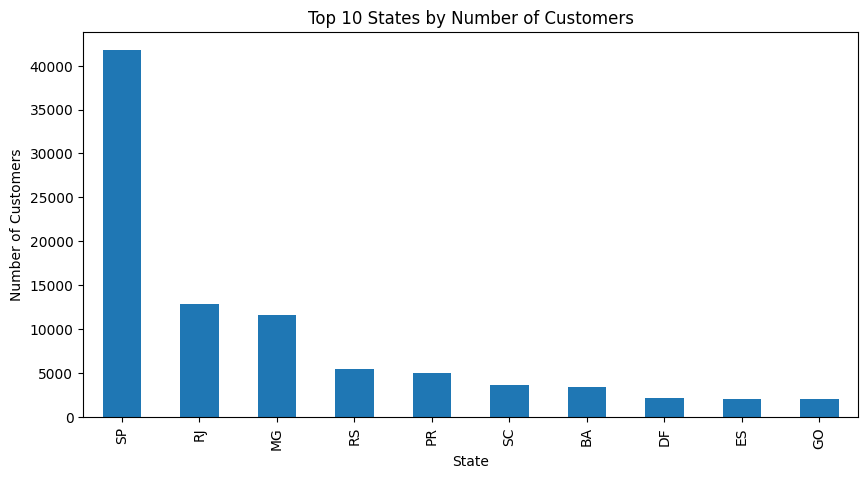

In [ ]:
plt.figure(figsize=(10,5))

customers['customer_state'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 States by Number of Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

# **2. olist_order_items_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1buHmISdlJcdQQPN0NLl33NSU5mvDXRYL/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
items = pd.read_csv(download_url)
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
eda_overview(items)

1.Shape: 
(112650, 7)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

3.Missing values: 
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

4.Duplicate values: 
0


In [ ]:
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64


In [ ]:
# Số items mỗi order
items_per_order = items.groupby('order_id')['order_item_id'].count()
items_per_order.describe()

,order_item_id
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [ ]:
items['price'].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [ ]:
items['freight_value'].describe()

,freight_value
count,112650.000000
mean,19.990320
std,15.806405
min,0.000000
25%,13.080000
50%,16.260000
75%,21.150000
max,409.680000


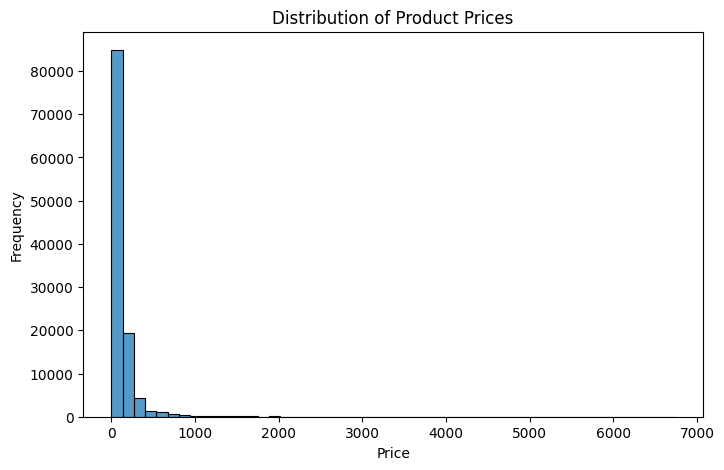

In [ ]:
# Price distribution
plt.figure(figsize=(8,5))

sns.histplot(items['price'], bins=50)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# **3. olist_order_payments_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1hUckmaVQglYBb6By7TDVQ4VfEfY1gHg0/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
payments = pd.read_csv(download_url)
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
eda_overview(payments)

1.Shape: 
(103886, 5)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB

3.Missing values: 
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

4.Duplicate values: 
0


In [ ]:
payments['order_id'].isna().sum()

np.int64(0)

In [ ]:
# Kiểm tra các loại payment
payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


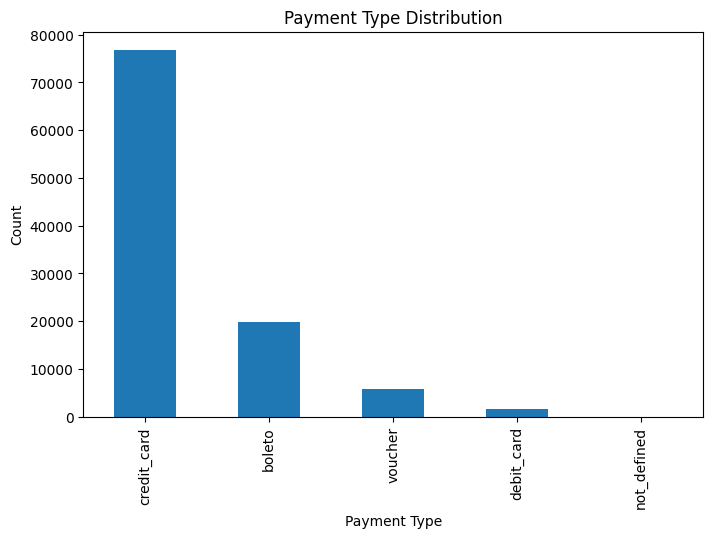

In [ ]:
# Payment Type Distribution
plt.figure(figsize=(8,5))

payments['payment_type'].value_counts().plot(kind='bar')

plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')

plt.show()

In [ ]:
payments['payment_installments'].value_counts().head(10)

,count
payment_installments,
1,52546
2,12413
3,10461
4,7098
10,5328
5,5239
8,4268
6,3920
7,1626


In [ ]:
payments['payment_installments'].describe()

,payment_installments
count,103886.000000
mean,2.853349
std,2.687051
min,0.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,24.000000


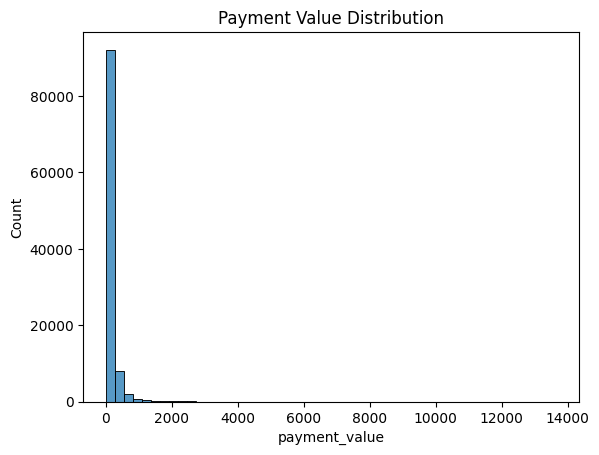

In [ ]:
# Payment Value Distribution
sns.histplot(payments['payment_value'], bins=50)
plt.title("Payment Value Distribution")
plt.show()

In [ ]:
payments['payment_value'].describe()

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [ ]:
payments['payment_value'].sum()

np.float64(16008872.12)

# **4. olist_order_reviews_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1PRAl4TkuOhROiWGdJdGlo7NabRdn6APn/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
reviews = pd.read_csv(download_url)
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
eda_overview(reviews)

1.Shape: 
(99224, 7)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

3.Missing values: 
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

4.Duplicate values: 
0


In [ ]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

In [ ]:
reviews['order_id'].nunique()

98673

In [ ]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [ ]:
reviews = reviews.drop_duplicates(subset='order_id')

In [ ]:
reviews['review_score'].value_counts().sort_index()

,count
review_score,
1,11353
2,3133
3,8124
4,19044
5,57019


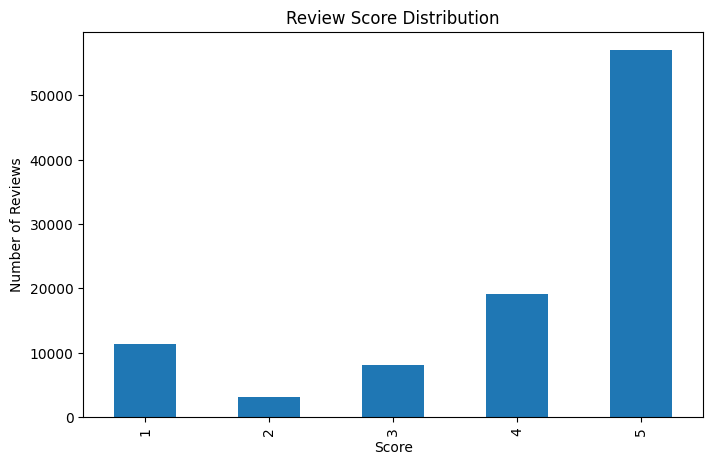

In [ ]:
plt.figure(figsize=(8,5))

reviews['review_score'].value_counts().sort_index().plot(kind='bar')

plt.title('Review Score Distribution')
plt.xlabel('Score')
plt.ylabel('Number of Reviews')

plt.show()

# **5. olist_orders_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1dy0aCg6V-KGqcrkssSAN_xyHUoInpTo9/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
orders = pd.read_csv(download_url)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
eda_overview(orders)

1.Shape: 
(99441, 8)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

3.Missing values: 
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrie

In [ ]:
# 1. Chuyển đổi các cột thời gian sang datetime
date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date']
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
# Feature engineering
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_day'] = orders['order_purchase_timestamp'].dt.day

# Delivery delay
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# Delivery time
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

In [ ]:
# Order status distribution
orders['order_status'].value_counts() / orders.shape[0] * 100

,count
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


<Axes: xlabel='order_status'>

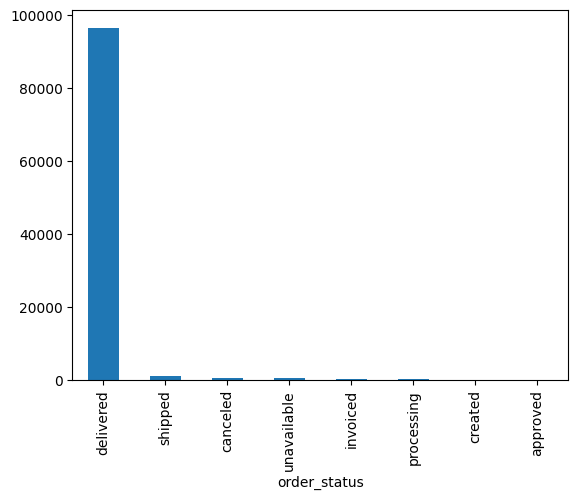

In [ ]:
#Plot
orders['order_status'].value_counts().plot(kind='bar')

In [ ]:
# chỉ lây đơn delivery
orders = orders[orders['order_status'] == 'delivered']
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 8   order_year                     96478 non-null  int32         
 9   order_month                    96478 non-null  int32         
 10  order_day                      96478 non-null  int32         
 11  delivery_delay_days 

# **6. olist_products_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1Jvzk_Z2BA3gOtXnLSyIAo9njhAKP_d8w/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
products = pd.read_csv(download_url)
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
eda_overview(products)

1.Shape: 
(32951, 9)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

3.Missing values: 
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty         

In [ ]:
# 1. Làm sạch bảng Products

products['product_category_name'] = products['product_category_name'].fillna('unknown')

# 2. Xử lý các cột thiếu thông số bằng median
columns = ['product_name_lenght',
                 'product_description_lenght',
                 'product_photos_qty',
                 'product_weight_g',
                 'product_length_cm',
                 'product_height_cm',
                 'product_width_cm']
for col in columns:
    products[col] = products[col].fillna(products[col].median())

# Kiểm tra lại một lần cuối
print(products[columns].isnull().sum())

product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


# **7. product_category_name_translation**

In [ ]:
url = r"https://drive.google.com/file/d/1n0hCqDI4yttNTHxmkan1y-6CLDzZ1B25/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
translation = pd.read_csv(download_url)
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
eda_overview(translation)

1.Shape: 
(71, 2)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

3.Missing values: 
product_category_name            0
product_category_name_english    0
dtype: int64

4.Duplicate values: 
0


In [ ]:
# Nối bảng Products và Translation
products = products.merge(
    translation,
    on='product_category_name',
    how='left')

eda_overview(products)

1.Shape: 
(32951, 10)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32951 non-null  object 
 2   product_name_lenght            32951 non-null  float64
 3   product_description_lenght     32951 non-null  float64
 4   product_photos_qty             32951 non-null  float64
 5   product_weight_g               32951 non-null  float64
 6   product_length_cm              32951 non-null  float64
 7   product_height_cm              32951 non-null  float64
 8   product_width_cm               32951 non-null  float64
 9   product_category_name_english  32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB

3.Missing values: 
product_id                         0
product_category_name          

In [ ]:
# Fill missing value product_category_name_english
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

In [ ]:
eda_overview(products)

1.Shape: 
(32951, 10)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32951 non-null  object 
 2   product_name_lenght            32951 non-null  float64
 3   product_description_lenght     32951 non-null  float64
 4   product_photos_qty             32951 non-null  float64
 5   product_weight_g               32951 non-null  float64
 6   product_length_cm              32951 non-null  float64
 7   product_height_cm              32951 non-null  float64
 8   product_width_cm               32951 non-null  float64
 9   product_category_name_english  32951 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB

3.Missing values: 
product_id                       0
product_category_name            

# **8. olist_sellers_dataset**

In [ ]:
url = r"https://drive.google.com/file/d/1ALXfpHcgBWGhVMlre9E4C-1Lvl8RtbHZ/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
sellers = pd.read_csv(download_url)
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
eda_overview(sellers)

1.Shape: 
(3095, 4)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

3.Missing values: 
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

4.Duplicate values: 
0


# **orders -> items -> products -> translation -> payments -> customers -> reviews -> sellers**

In [ ]:
# 1 orderID là 1 row
payments_agg = payments.groupby('order_id').agg({
    'payment_value':'sum',
    'payment_installments':'max'
}).reset_index()

In [ ]:
# Merge all tables to create master dataset
df = (
    orders
    .merge(items, on='order_id', how='left')
    .merge(products, on='product_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(customers, on='customer_id', how='left')
    .merge(reviews, on='order_id', how='left')
    .merge(sellers, on='seller_id', how='left')
)

eda_overview(df)

1.Shape: 
(110197, 43)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_year                     110197 non-null  int32         
 9   order_month                    110197 non-null  int32         
 10  order_day                      11019

In [ ]:
df.duplicated(subset=['order_id','order_item_id']).sum()

np.int64(0)

In [ ]:
df['product_category_name'] = df['product_category_name'].fillna('unknown')
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

In [ ]:
# Chỉ lấy Order delivery
df = df[df['order_status'] == 'delivered']

In [ ]:
# Revenue Column
df['revenue'] = df['price'] * df['order_item_id']

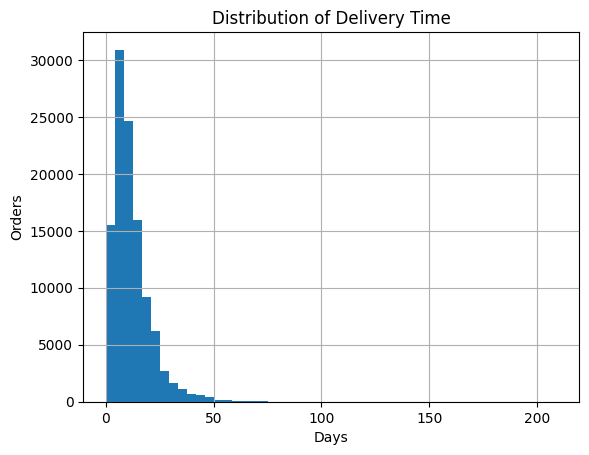

In [ ]:
# Visual Delivery time
df['delivery_time_days'].hist(bins=50)

plt.title('Distribution of Delivery Time')
plt.xlabel('Days')
plt.ylabel('Orders')
plt.show()

In [ ]:
df[['delivery_time_days','delivery_delay_days']].describe()

,delivery_time_days,delivery_delay_days
count,110189.000000,110189.000000
mean,12.007342,-12.029041
std,9.451153,10.158194
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-13.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [ ]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,2
order_delivered_customer_date,8
order_estimated_delivery_date,0
order_year,0
order_month,0


In [ ]:
# Revenue by Month
revenue_by_month = df.groupby('order_month')['revenue'].sum()
revenue_by_month

,revenue
order_month,
1,1178555.01
2,1208520.94
3,1472304.12
4,1473555.21
5,1660203.07
6,1425461.46
7,1518713.83
8,1566666.67
9,737059.28


Text(0, 0.5, 'Revenue')

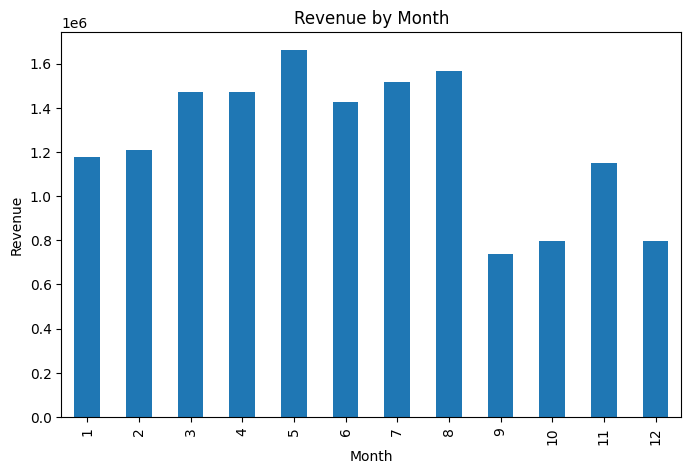

In [ ]:
# visual Revenue by Month
plt.figure(figsize=(8,5))

revenue_by_month.plot(kind='bar')

plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')

In [ ]:
# Orders by Month
orders_by_month = df.groupby('order_month')['order_id'].count()
orders_by_month

,order_id
order_month,
1,8950
2,9376
3,10914
4,10396
5,11814
6,10499
7,11379
8,11939
9,4740


Text(0, 0.5, 'Number of Orders')

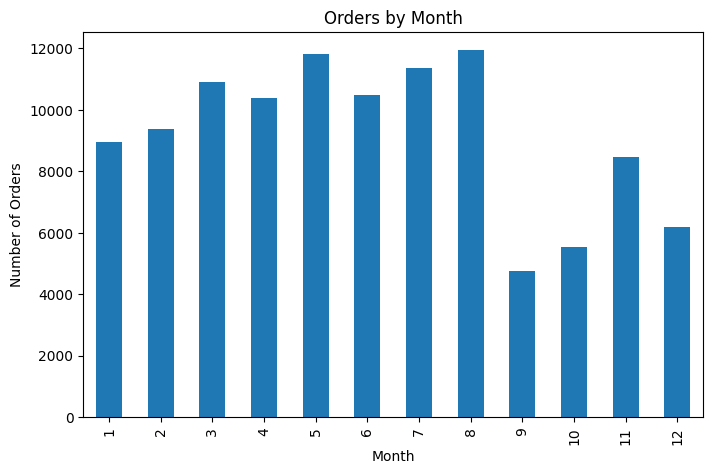

In [ ]:
# Visual Orders by Month
plt.figure(figsize=(8,5))

orders_by_month.plot(kind='bar')

plt.title('Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

Text(0, 0.5, 'Revenue')

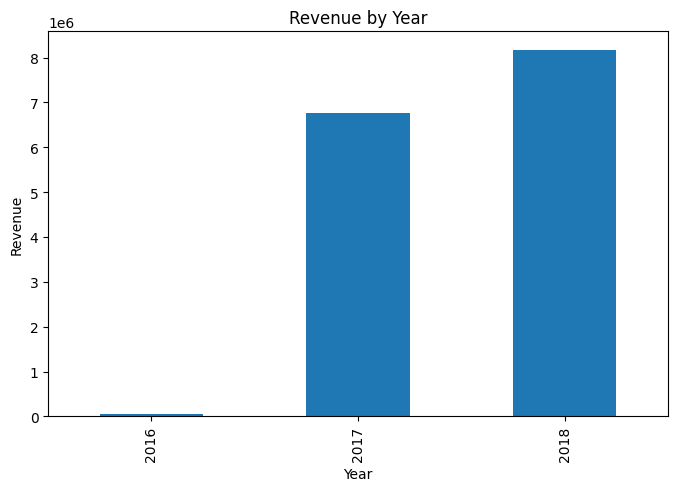

In [ ]:
# Revenue by Year
revenue_by_year = df.groupby('order_year')['revenue'].sum()

# Visual Revenue by Year
plt.figure(figsize=(8,5))

revenue_by_year.plot(kind='bar')

plt.title('Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

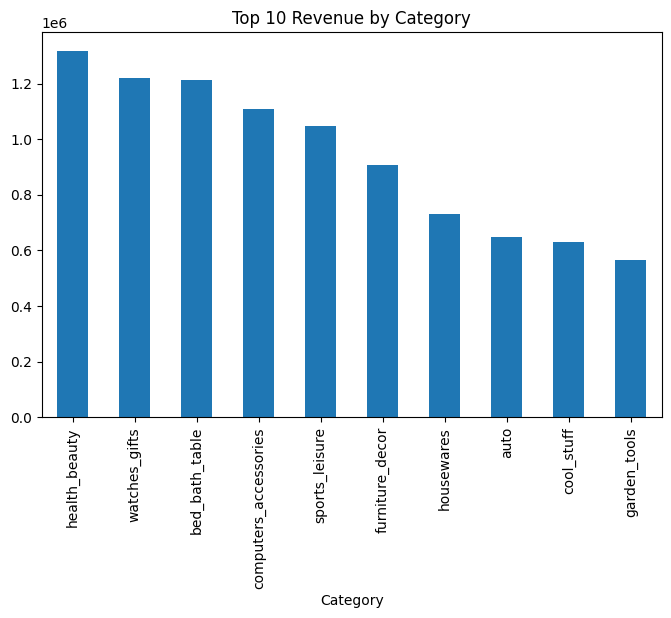

In [ ]:
# Revenue by category
revenue_by_category = df.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False)

# Top 10 Revenue by category
top_10_revenue_by_category = revenue_by_category.head(10)

# Visual
plt.figure(figsize=(8,5))

top_10_revenue_by_category.plot(kind='bar')

plt.title('Top 10 Revenue by Category')
plt.xlabel('Category')
plt

In [ ]:
# delivery delay ảnh hưởng tới review score?
df.groupby('review_score')['delivery_delay_days'].mean()

,delivery_delay_days
review_score,
1.0,-5.925685
2.0,-9.718997
3.0,-11.084395
4.0,-12.486430
5.0,-13.418504


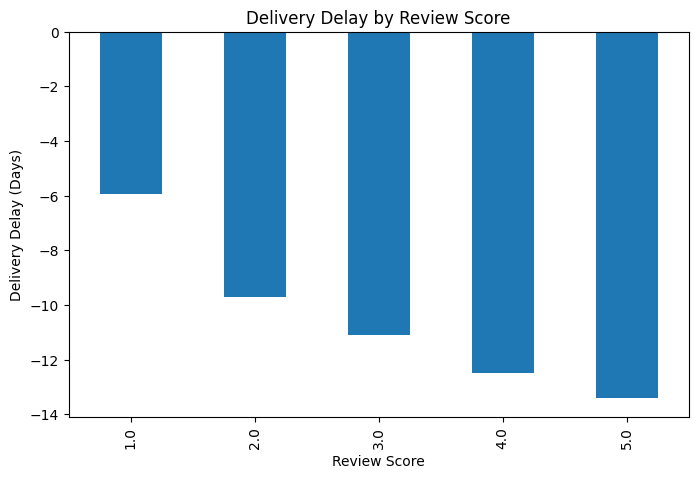

In [ ]:
 # Visual delivery delay ảnh hưởng tới review score
plt.figure(figsize=(8,5))
df.groupby('review_score')['delivery_delay_days'].mean().plot(kind='bar')
plt.title('Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (Days)')
plt.show()

<Axes: title={'center': 'delivery_delay_days'}, xlabel='review_score'>

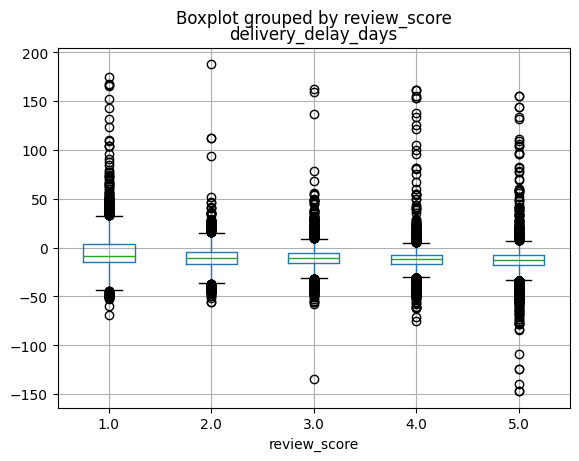

In [ ]:
df.boxplot(column='delivery_delay_days', by='review_score')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_year                     110197 non-null  int32         
 9   order_month                    110197 non-null  int32         
 10  order_day                      110197 non-null  int32         
 11  

In [ ]:
df['payment_value'] = df['payment_value'].fillna(0)

## **Customer Segmentation**

In [ ]:
# B1: Tạo order-level dataset => Tránh double revenue, 1 order là 1 row duy nhất
orders_rfm = df.groupby('order_id').agg({
    'customer_unique_id':'first',
    'order_purchase_timestamp':'first',
    'payment_value':'first'
}).reset_index()

orders_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_unique_id        96478 non-null  object        
 2   order_purchase_timestamp  96478 non-null  datetime64[ns]
 3   payment_value             96478 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 2.9+ MB


In [ ]:
#  B2: Tạo ngày phân tích (analysis date)
analysis_date = orders_rfm['order_purchase_timestamp'].max() + pd.Timedelta(days=1) #lấy ngày cuối dataset + 1 ngày

In [ ]:
# Recency, Frequency, Monetary
rfm = orders_rfm.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days, # Recency
    'order_id': 'count',   # Frequency
    'payment_value': 'sum' # Monetary
}).reset_index()

In [ ]:
rfm.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [ ]:
rfm.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


# **RFM Score**

In [ ]:
# R_score
rfm['R_score'] = pd.qcut(rfm['recency'],5,labels=[5,4,3,2,1])

In [ ]:
# F_score
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),5,labels=[1,2,3,4,5])

In [ ]:
# M_score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),5,labels=[1,2,3,4,5])

In [ ]:
# Điểm tổng RFM_score

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

# **Tạo Customer Segments**

In [ ]:
# Most customers in the dataset are one-time buyers,
# making Frequency a weak differentiator in RFM segmentation.

def segment(row):

    if row['R_score'] >=4 and row['M_score'] >=4:
        return 'Champions'

    elif row['R_score'] >=3 and row['M_score'] >=3:
        return 'Loyal Customers'

    elif row['R_score'] >=4:
        return 'New Customers'

    elif row['R_score'] <=2 and row['M_score'] >=3:
        return 'At Risk'

    else:
        return 'Churned'

rfm['segment'] = rfm.apply(segment,axis=1)

In [ ]:
eda_overview(rfm)

1.Shape: 
(93358, 9)

2.Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customer_unique_id  93358 non-null  object  
 1   recency             93358 non-null  int64   
 2   frequency           93358 non-null  int64   
 3   monetary            93358 non-null  float64 
 4   R_score             93358 non-null  category
 5   F_score             93358 non-null  category
 6   M_score             93358 non-null  category
 7   RFM_score           93358 non-null  object  
 8   segment             93358 non-null  object  
dtypes: category(3), float64(1), int64(2), object(3)
memory usage: 4.5+ MB

3.Missing values: 
customer_unique_id    0
recency               0
frequency             0
monetary              0
R_score               0
F_score               0
M_score               0
RFM_score             0
segment               0
d

In [ ]:
rfm['segment'].value_counts(normalize=True)

,proportion
segment,
Churned,0.245635
At Risk,0.233917
Loyal Customers,0.200743
Champions,0.165342
New Customers,0.154363


In [ ]:
rfm.groupby('segment')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
segment,,,
At Risk,393.912492,1.044967,242.500360
Champions,91.424398,1.075862,306.623237
Churned,338.310222,1.004840,55.359690
Loyal Customers,167.986340,1.041673,178.000863
New Customers,89.786830,1.005204,54.699884


# **1.Tạo bảng dim_customers_rfm**

In [ ]:
customer_info = (
    df.sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .agg({
        'customer_city':'last',
        'customer_state':'last'
    })
    .reset_index()
)

In [ ]:
dim_customers_rfm = rfm.merge(
                      customer_info,
                      on='customer_unique_id',
                      how='left'
                      )

dim_customers_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customer_unique_id  93358 non-null  object  
 1   recency             93358 non-null  int64   
 2   frequency           93358 non-null  int64   
 3   monetary            93358 non-null  float64 
 4   R_score             93358 non-null  category
 5   F_score             93358 non-null  category
 6   M_score             93358 non-null  category
 7   RFM_score           93358 non-null  object  
 8   segment             93358 non-null  object  
 9   customer_city       93358 non-null  object  
 10  customer_state      93358 non-null  object  
dtypes: category(3), float64(1), int64(2), object(5)
memory usage: 6.0+ MB


In [ ]:
dim_customers_rfm['customer_unique_id'].duplicated().sum()

np.int64(0)

In [ ]:
#dim_customers_rfm.to_csv('dim_customers_rfm.csv', index=False, encoding='utf-8-sig')

# **2.Tạo bảng fact_orders**

In [ ]:
fact_orders = (orders_rfm
    .merge(orders[['order_id','delivery_time_days','delivery_delay_days']],
           on='order_id',
           how='left')
    .merge(reviews[['order_id','review_score']],
           on='order_id',
           how='left')
)
fact_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_unique_id        96478 non-null  object        
 2   order_purchase_timestamp  96478 non-null  datetime64[ns]
 3   payment_value             96478 non-null  float64       
 4   delivery_time_days        96470 non-null  float64       
 5   delivery_delay_days       96470 non-null  float64       
 6   review_score              95832 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 5.2+ MB


In [ ]:
fact_orders['order_id'].duplicated().sum()

np.int64(0)

In [ ]:
#fact_orders.to_csv('fact_orders.csv', index=False, encoding='utf-8-sig')

# **3.Tạo bảng date_dim**

In [ ]:
date_range = pd.date_range(
    start=fact_orders['order_purchase_timestamp'].min(),
    end=fact_orders['order_purchase_timestamp'].max()
)

dim_date = pd.DataFrame({'date': date_range})

dim_date['year'] = date_dim['date'].dt.year
dim_date['month'] = date_dim['date'].dt.month
dim_date['month_name'] = date_dim['date'].dt.strftime('%B')
dim_date['quarter'] = date_dim['date'].dt.quarter
dim_date['year_month'] = date_dim['date'].dt.to_period('M').astype(str)
dim_date['week'] = date_dim['date'].dt.isocalendar().week

In [ ]:
dim_date.head()

,date,year,month,month_name,quarter,year_month,week
0,2016-09-15 12:16:38,2016,9,September,3,2016-09,37
1,2016-09-16 12:16:38,2016,9,September,3,2016-09,37
2,2016-09-17 12:16:38,2016,9,September,3,2016-09,37
3,2016-09-18 12:16:38,2016,9,September,3,2016-09,37
4,2016-09-19 12:16:38,2016,9,September,3,2016-09,38


In [ ]:
#dim_date.to_csv('dim_date.csv', index=False, encoding='utf-8-sig')

# **4.Tạo bảng fact_order_items**

In [ ]:
fact_order_items = items[[
    'order_id',
    'order_item_id',
    'product_id',
    'seller_id',
    'price',
    'freight_value'
]].copy()

# thêm quantity
fact_order_items['quantity'] = 1

# thêm total value
fact_order_items['total_item_value'] = fact_order_items['price'] + fact_order_items['freight_value']

In [ ]:
fact_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          112650 non-null  object 
 1   order_item_id     112650 non-null  int64  
 2   product_id        112650 non-null  object 
 3   seller_id         112650 non-null  object 
 4   price             112650 non-null  float64
 5   freight_value     112650 non-null  float64
 6   quantity          112650 non-null  int64  
 7   total_item_value  112650 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 6.9+ MB


In [ ]:
fact_order_items.duplicated(subset=['order_id', 'product_id', 'seller_id']).sum()

np.int64(10225)

In [ ]:
#from google.colab import files
#files.download('fact_order_items.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **5.Tạo bảng dim_products**

In [ ]:
dim_products = products[['product_id', 'product_category_name_english']].copy()
dim_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_id                     32951 non-null  object
 1   product_category_name_english  32951 non-null  object
dtypes: object(2)
memory usage: 515.0+ KB


In [ ]:
#dim_products.to_csv('dim_products.csv', index=False, encoding='utf-8-sig')

# **6.Tạo bảng dim_sellers**

In [ ]:
dim_sellers = sellers[['seller_id', 'seller_city', 'seller_state']].copy()
dim_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   seller_id     3095 non-null   object
 1   seller_city   3095 non-null   object
 2   seller_state  3095 non-null   object
dtypes: object(3)
memory usage: 72.7+ KB


In [ ]:
#dim_sellers.to_csv('dim_sellers.csv', index=False, encoding='utf-8-sig')